In [1]:
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from scipy.cluster.hierarchy import linkage, dendrogram,fcluster
from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import umap
import hdbscan


In [2]:
data_dir = "results"
file_list = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])
vectorized_data = []

for fname in file_list:
    matrix = np.load(os.path.join(data_dir, fname))
    vector = matrix.flatten()
    
    # Normalize the vector using L2 norm
    norm_vector = normalize(vector.reshape(1, -1), norm='l2')[0]
    vectorized_data.append(vector)

X = np.vstack(vectorized_data)
print("Shape of X:", X.shape)

Shape of X: (129, 16320)


In [3]:
filenames = [os.path.splitext(f)[0] for f in file_list]

In [4]:
use_umap = True

if use_umap:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    X_2d = reducer.fit_transform(X)
else:
    X_2d = PCA(n_components=2).fit_transform(X)

n_clusters = 8

/Users/floyd/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


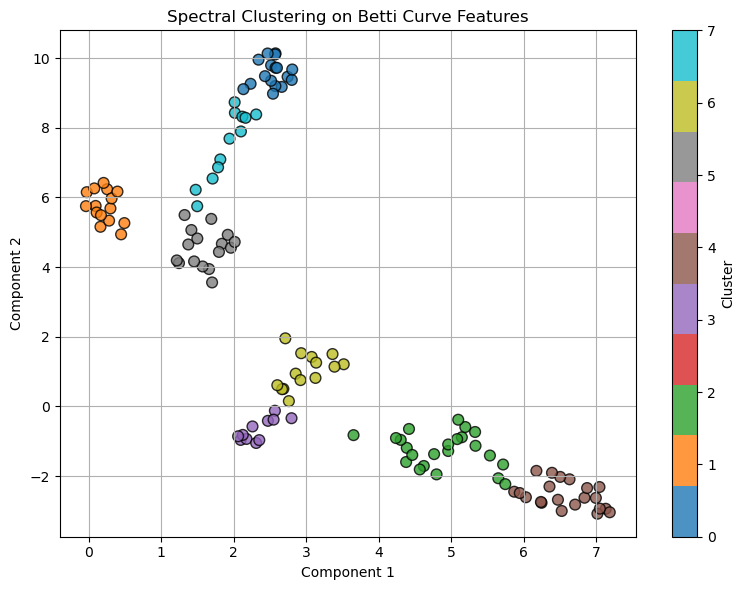

In [5]:
spectral = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',
    assign_labels='kmeans',
    random_state=42
)
labels = spectral.fit_predict(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=labels,
    cmap='tab10',
    s=60,
    edgecolor='k',
    alpha=0.8
)
plt.title("Spectral Clustering on Betti Curve Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.savefig("Spectral_cls8.png", format='png', bbox_inches='tight')
plt.show()

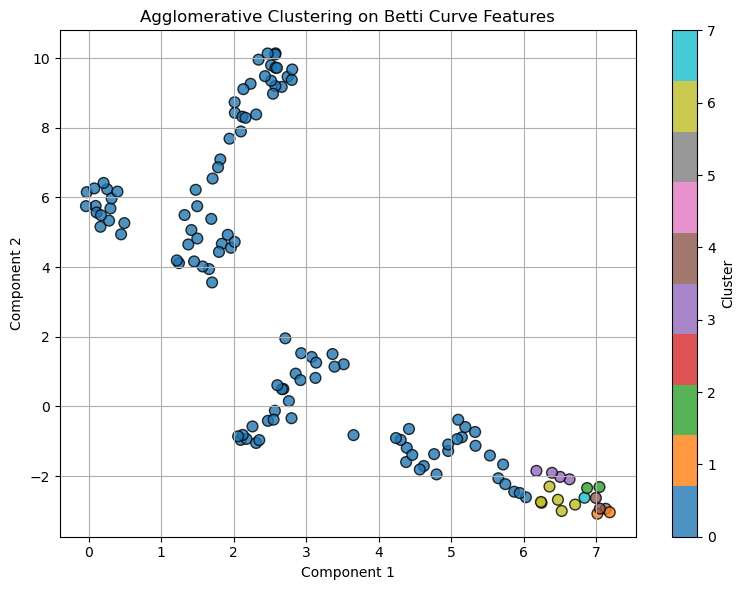

In [6]:
agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')  # linkage: 'average', 'complete', 'single'
labels = agglo.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=60, edgecolor='k', alpha=0.8)
plt.title("Agglomerative Clustering on Betti Curve Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.savefig("Agglomerative_cls8.png", format='png', bbox_inches='tight')
plt.show()

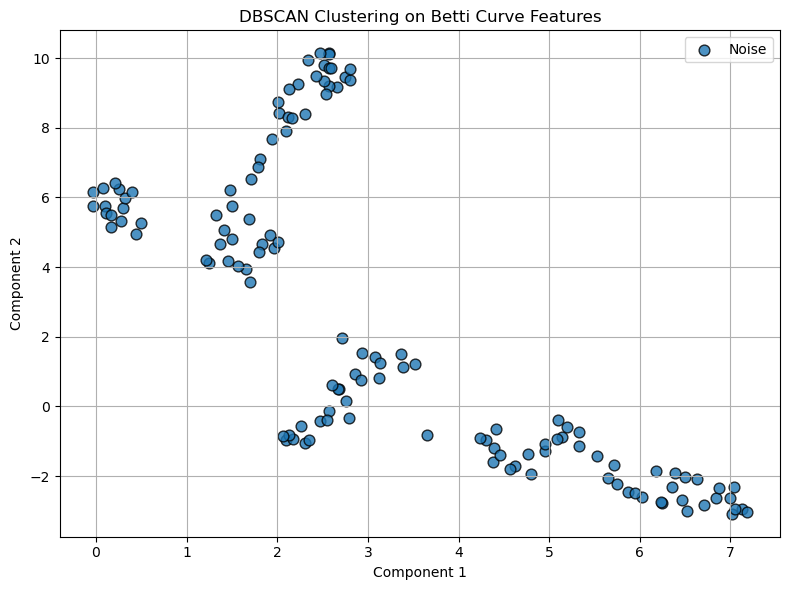

In [7]:
dbscan = DBSCAN(eps=0.2, min_samples=5) #min_samples adjust based on data density(4-10)
labels = dbscan.fit_predict(X)

plt.figure(figsize=(8, 6))

unique_labels = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = labels == label
    label_name = f"Cluster {label}" if label != -1 else "Noise"
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        label=label_name,
        s=60, edgecolor='k', alpha=0.8, color=color
    )

plt.title("DBSCAN Clustering on Betti Curve Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("DBSCAN_cls_02_5.png", format='png', bbox_inches='tight')
plt.show()

/Users/floyd/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/floyd/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


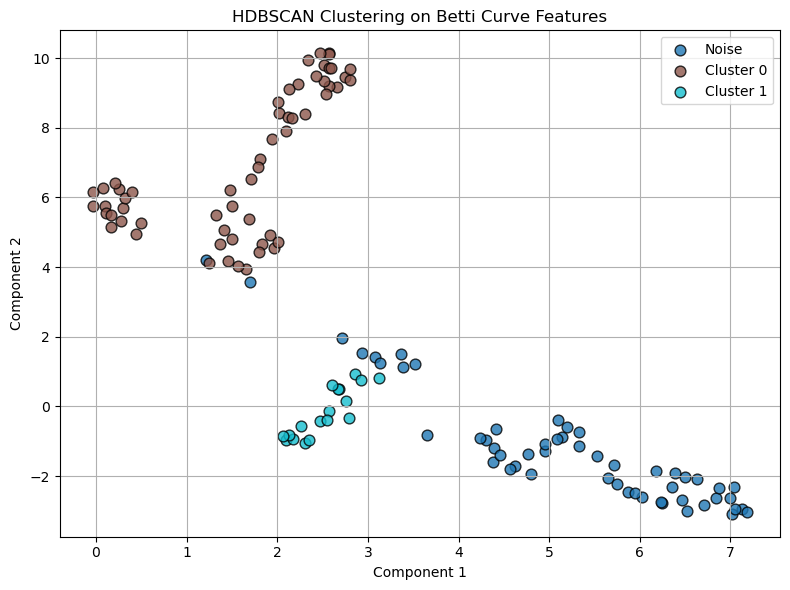

In [8]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=6, min_samples=4) #adjust parameters
labels = clusterer.fit_predict(X)

plt.figure(figsize=(8, 6))
unique_labels = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = labels == label
    label_text = f"Cluster {label}" if label != -1 else "Noise"
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=label_text,
        s=60,
        edgecolor='k',
        alpha=0.8,
        color=color
    )

plt.title("HDBSCAN Clustering on Betti Curve Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("HDBSCAN_cls_6_4.png", format='png', bbox_inches='tight')
plt.show()

In [9]:
#K-mean
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

cluster_df = pd.DataFrame({
    'field': filenames,
    'cluster': labels
})

print(cluster_df.head())
print(cluster_df.sort_values(by='cluster'))

                                    field  cluster
0  Accounting Auditing and Accountability        2
1                   Aerospace Engineering        3
2              Agricultural Biotechnology        3
3    Agriculture Land and Farm Management        3
4                    Analytical Chemistry        0
                             field  cluster
73                Literary Studies        0
94                 Optical Physics        0
95               Organic Chemistry        0
98         Other Chemical Sciences        0
23            Chemical Engineering        0
..                             ...      ...
17  Banking Finance and Investment        6
46                    Econometrics        6
14            Atmospheric Sciences        6
37     Crop and Pasture Production        7
91                    Oceanography        7

[129 rows x 2 columns]


In [10]:
pca = PCA(n_components=2, random_state=1)
X_2d = pca.fit_transform(X)

/var/folders/v9/_js75nzx64lf8__fmfsscg4c0000gn/T/ipykernel_48281/3535064491.py:19: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, ticks=range(n_clusters))


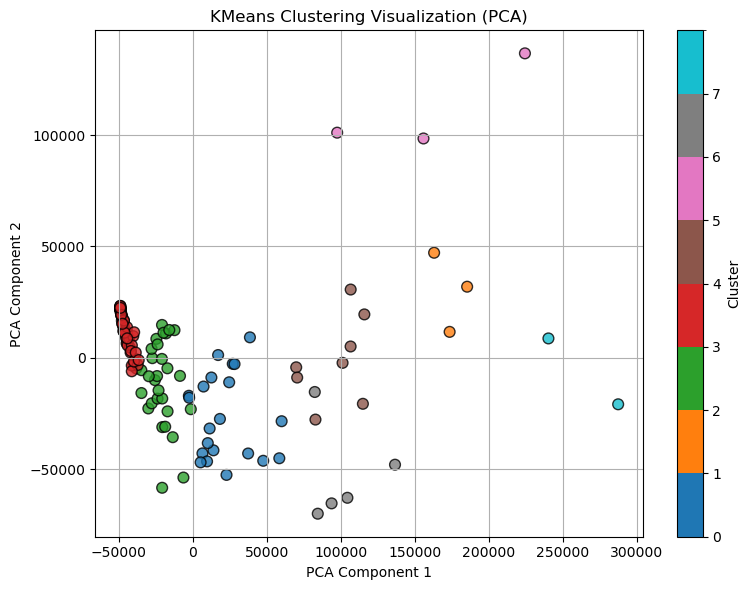

In [11]:
cmap = plt.get_cmap('tab10')
norm = BoundaryNorm(boundaries=range(n_clusters+1), ncolors=cmap.N)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels,
    cmap=cmap,
    norm=norm,
    s=60,
    alpha=0.8,
    edgecolor='k'
)

# colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # dummy array
cbar = plt.colorbar(sm, ticks=range(n_clusters))
cbar.set_label('Cluster')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clustering Visualization (PCA)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
kmedoids = KMedoids(n_clusters=n_clusters, random_state=42, method='pam', init='k-medoids++')
labels_med = kmedoids.fit_predict(X)

medoid_indices = kmedoids.medoid_indices_
medoids = X[medoid_indices]

cluster_df = pd.DataFrame({
    'field': filenames,
    'cluster': labels_med
})
print(cluster_df.head())
print(cluster_df.sort_values(by='cluster'))

                                    field  cluster
0  Accounting Auditing and Accountability        4
1                   Aerospace Engineering        7
2              Agricultural Biotechnology        0
3    Agriculture Land and Farm Management        7
4                    Analytical Chemistry        1
                                         field  cluster
90                     Nutrition and Dietetics        0
31      Complementary and Alternative Medicine        0
33                           Computer Hardware        0
99                             Other Economics        0
39              Curatorial and Related Studies        0
..                                         ...      ...
54                          Fisheries Sciences        7
55                               Food Sciences        7
60   History and Philosophy of Specific Fields        7
70                            Language Studies        7
128                                    Zoology        7

[129 rows x 2 columns

In [13]:
print("\nMedoid indices:", medoid_indices)
print("Medoid filenames:", [filenames[idx] for idx in medoid_indices])


Medoid indices: [ 69  98 103  67  52  64  37  54]
Medoid filenames: ['Journalism and Professional Writing', 'Other Chemical Sciences', 'Other Physical Sciences', 'Inorganic Chemistry', 'Evolutionary Biology', 'Immunology', 'Crop and Pasture Production', 'Fisheries Sciences']


In [14]:
pca_med = PCA(n_components=2, random_state=2)
X_2d_med = pca_med.fit_transform(X)
medoids_2d = X_2d_med[medoid_indices]

/var/folders/v9/_js75nzx64lf8__fmfsscg4c0000gn/T/ipykernel_48281/517668178.py:25: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, ticks=range(n_clusters))


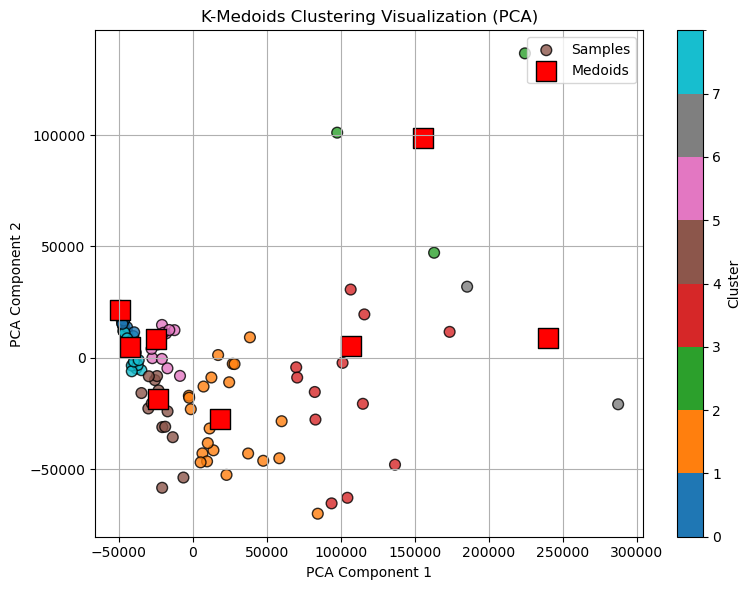

In [15]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d_med[:, 0], X_2d_med[:, 1],
    c=labels_med,
    cmap=cmap,
    norm=norm,
    s=60,
    alpha=0.8,
    edgecolor='k',
    label='Samples'
)

plt.scatter(
    medoids_2d[:, 0], medoids_2d[:, 1],
    c='red',
    marker='s',
    s=200,
    edgecolor='black',
    label='Medoids'
)

# colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=range(n_clusters))
cbar.set_label('Cluster')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Medoids Clustering Visualization (PCA)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Kmedoid_cls8.png", format='png', bbox_inches='tight')
plt.show()

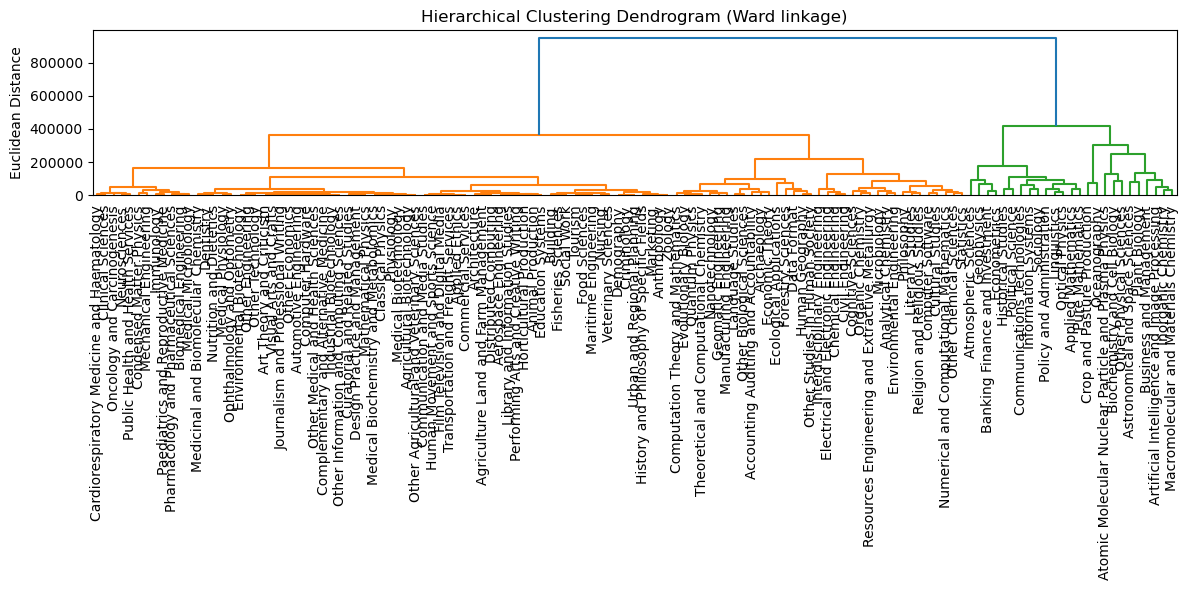

In [16]:
#Hierachical

distance_matrix = pdist(X, metric='euclidean')
Z = linkage(distance_matrix, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=filenames,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None
)

plt.ylabel('Euclidean Distance')
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.tight_layout()
plt.savefig("Hierachical_cls.png", format='png', bbox_inches='tight')
plt.show()